In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


## Simulaatio

In [4]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [5]:
def find_params(q,A,evolution,f_rabi,AC_stark, lims, scale):

    #Rajat AC-stark siirtymälle
    min_range = lims[0]
    max_range = lims[1]

    f_d = q.frequency/3 #Ajotaajuus
    
    #Arvot eri ajotaajuuksille/AC-stark siirtymille
    pulse_times=[]
    max_e_vals=[]
    max_f_vals=[]
    AC_stark_vals=[]
    
    for i in range(min_range,max_range):
        delta=AC_stark+i/scale #AC-stark siirtymä
        AC_stark_vals.append(delta)

        sim_vals = pulses.sim_3_part_pulses(f_d+delta,f_ef,A,evolution,dim,f_rabi,t_ramp=10,U_f=1)

        max_e_vals.append(sim_vals[0])
        max_f_vals.append(sim_vals[1])
        pulse_times.append(sim_vals[2])

    plt.figure()
    plt.plot(AC_stark_vals, max_e_vals)
    plt.xlabel("delta=ω_d-ω_q/3 (GHz)")
    plt.ylabel("Suurin e-tason todennäköisyys")
    plt.show()
    
    index=np.argmax(max_e_vals)
    AC_stark=AC_stark_vals[index]
    e_max=max_e_vals[index]
    f_max=max_f_vals[index]
    pi_pulse=pulse_times[index]
    
    return(AC_stark,pi_pulse,[e_max,f_max],max_e_vals)

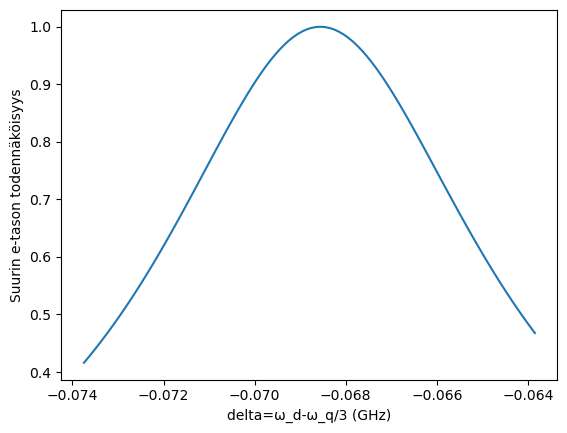

Amplitudi (GHz): 5.862378319584331
AC-stark siirtymä (GHz): -0.06854670085959742
E-tason suurin todennäköisyys: 0.9999926759002367
Pulssin pituus (ns): 248.88195738790156
Rabi-taajuus (fourier):  0.001997862955250715


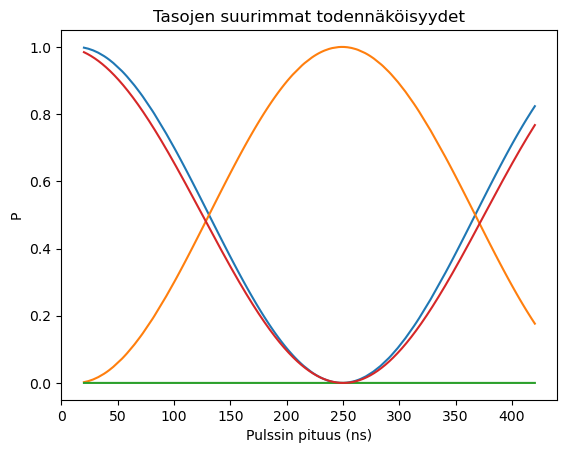

---------------------------------------------


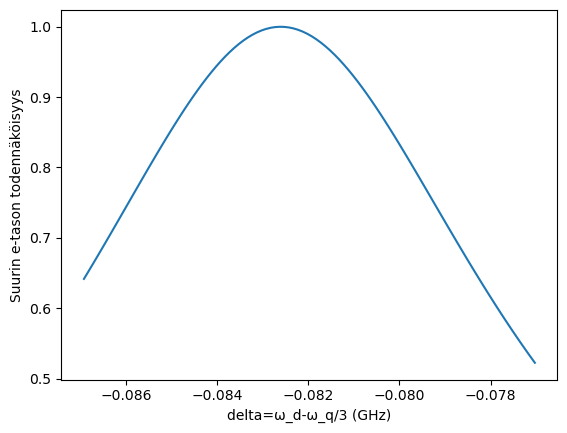

Amplitudi (GHz): 6.425810560825846
AC-stark siirtymä (GHz): -0.08262749439295047
E-tason suurin todennäköisyys: 0.9999867478745655
Pulssin pituus (ns): 191.76205947401442
Rabi-taajuus (fourier):  0.002827783917946332


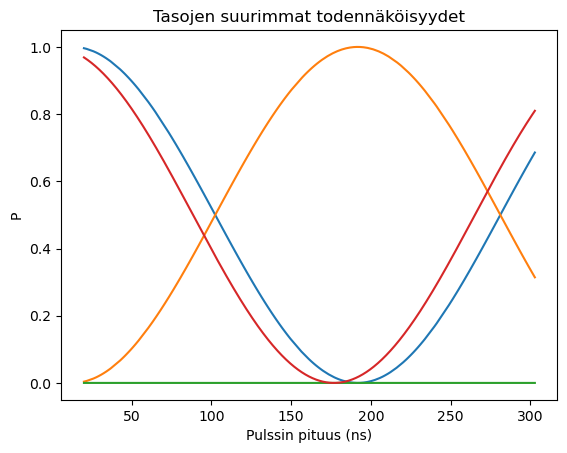

---------------------------------------------

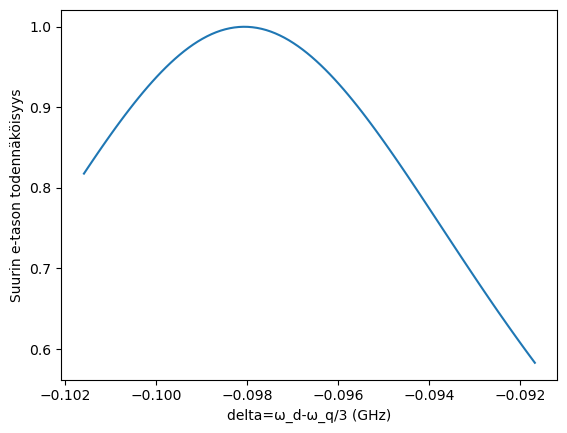

Amplitudi (GHz): 6.98924280206736
AC-stark siirtymä (GHz): -0.09808382290521009
E-tason suurin todennäköisyys: 0.9999911238633302
Pulssin pituus (ns): 151.67721543211465
Rabi-taajuus (fourier):  0.0037577979995352755


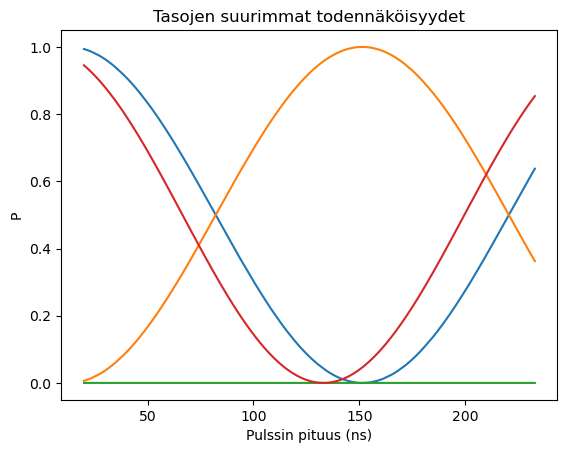

---------------------------------------------


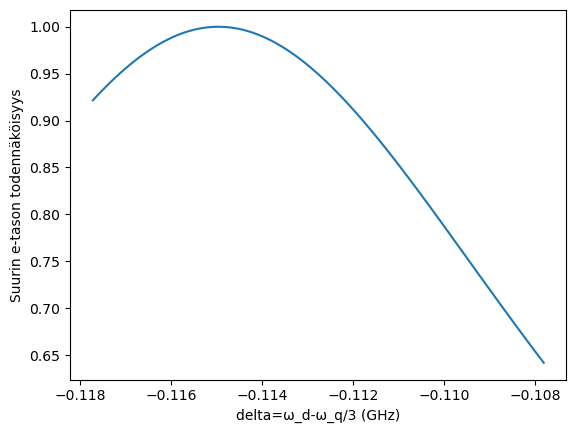

Amplitudi (GHz): 7.5526750433088745
AC-stark siirtymä (GHz): -0.1149156863963763
E-tason suurin todennäköisyys: 0.9999791620575094
Pulssin pituus (ns): 121.95491795540768
Rabi-taajuus (fourier):  0.0048193032621909725


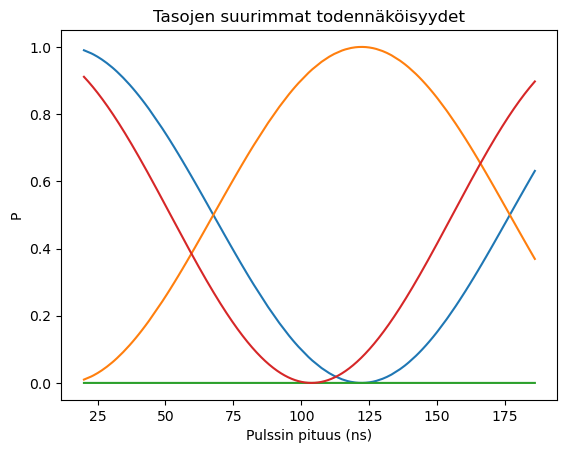

---------------------------------------------


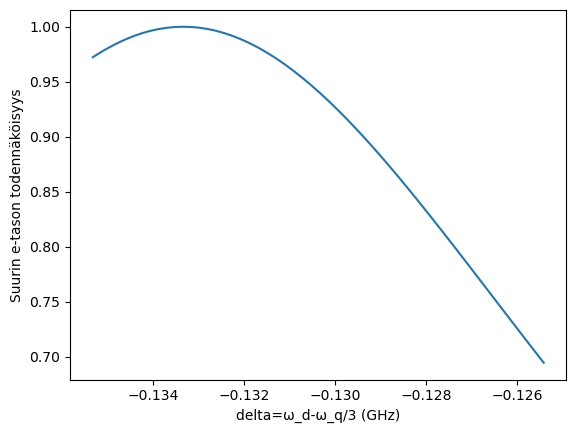

Amplitudi (GHz): 8.11610728455039
AC-stark siirtymä (GHz): -0.13332308486644914
E-tason suurin todennäköisyys: 0.9999984531709478
Pulssin pituus (ns): 100.39108998689407
Rabi-taajuus (fourier):  0.006043616758419821


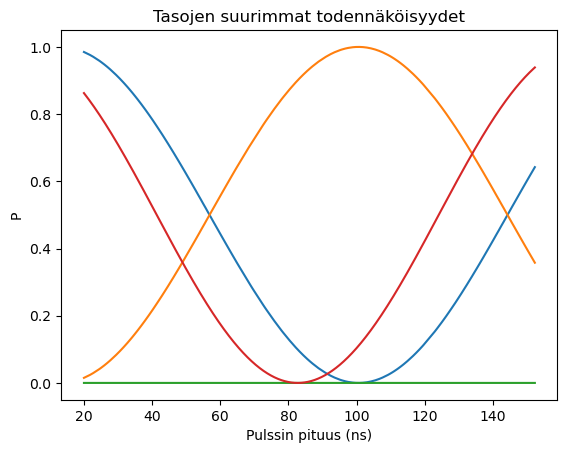

---------------------------------------------

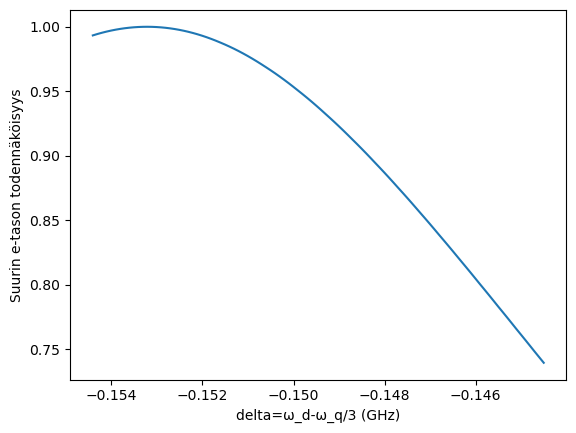

Amplitudi (GHz): 8.679539525791904
AC-stark siirtymä (GHz): -0.15320601831542852
E-tason suurin todennäköisyys: 0.9999390948963529
Pulssin pituus (ns): 84.01427624585332
Rabi-taajuus (fourier):  0.007462594716139585


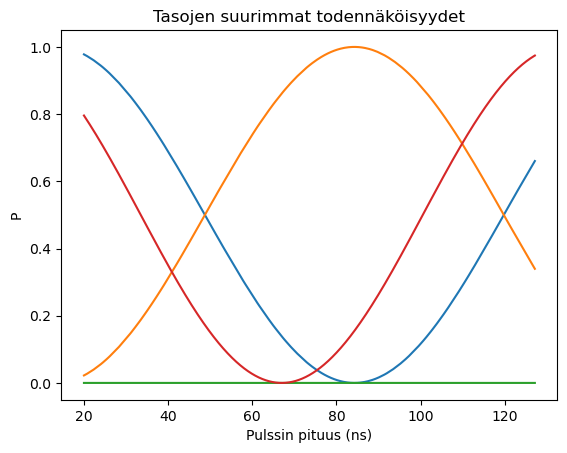

---------------------------------------------


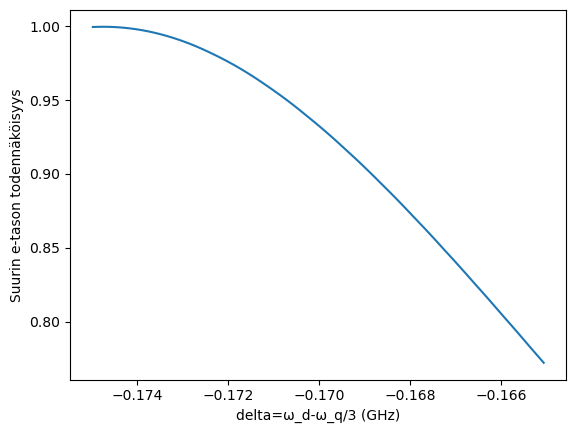

Amplitudi (GHz): 9.242971767033419
AC-stark siirtymä (GHz): -0.1747644867433145
E-tason suurin todennäköisyys: 0.9996426698317941
Pulssin pituus (ns): 72.09915541305195
Rabi-taajuus (fourier):  0.009107083852641373


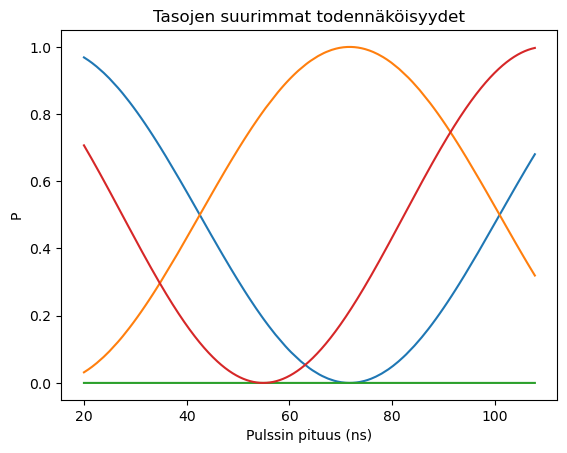

---------------------------------------------


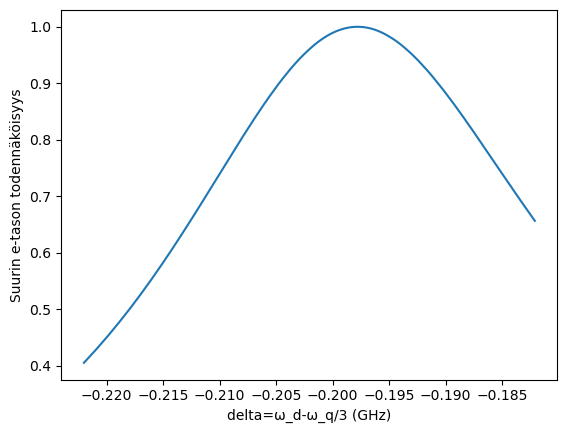

Amplitudi (GHz): 9.806404008274933
AC-stark siirtymä (GHz): -0.1977984901501071
E-tason suurin todennäköisyys: 0.999842135766934
Pulssin pituus (ns): 61.64358306799366
Rabi-taajuus (fourier):  0.011008964365878712


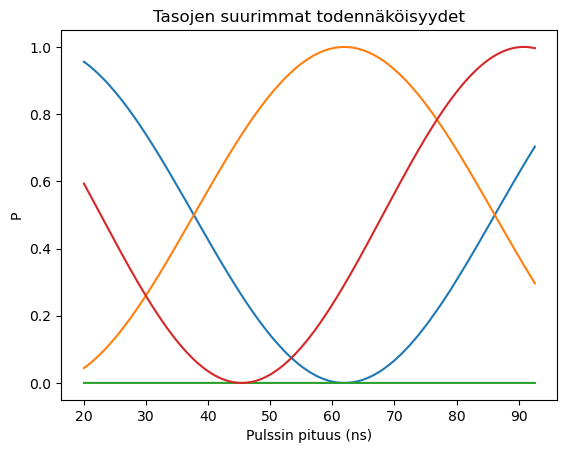

---------------------------------------------


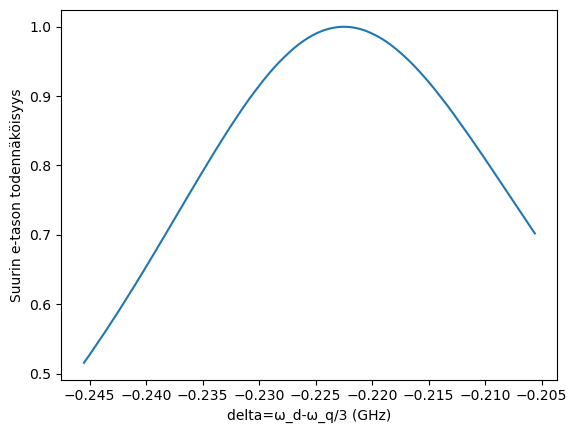

Amplitudi (GHz): 10.369836249516448
AC-stark siirtymä (GHz): -0.22250802853580623
E-tason suurin todennäköisyys: 0.999908471001111
Pulssin pituus (ns): 54.17377924753972
Rabi-taajuus (fourier):  0.011549421551376997


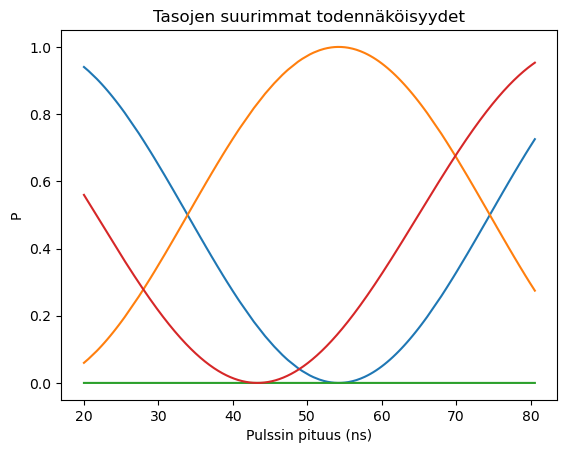

---------------------------------------------


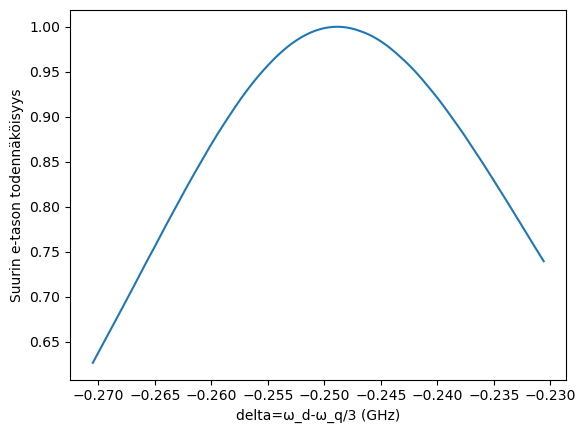

Amplitudi (GHz): 10.933268490757962
AC-stark siirtymä (GHz): -0.24889310190041194
E-tason suurin todennäköisyys: 0.9999350753172572
Pulssin pituus (ns): 48.188334226212035
Rabi-taajuus (fourier):  0.013746556158295455


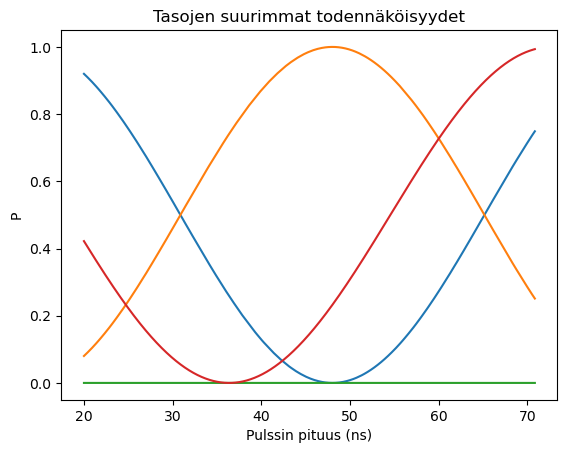

---------------------------------------------


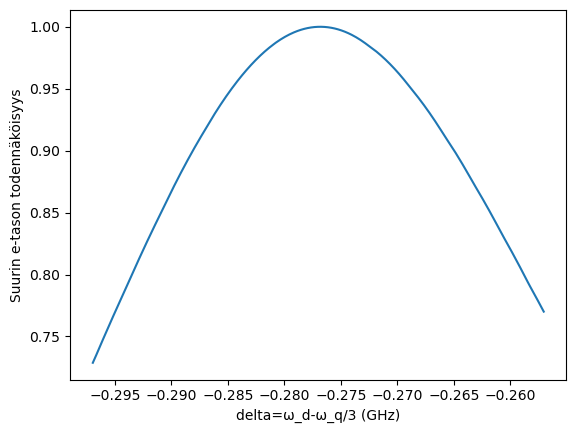

Amplitudi (GHz): 11.496700731999479
AC-stark siirtymä (GHz): -0.27685371024392436
E-tason suurin todennäköisyys: 0.9999611094649057
Pulssin pituus (ns): 42.933155746030806
Rabi-taajuus (fourier):  0.016250306393960662


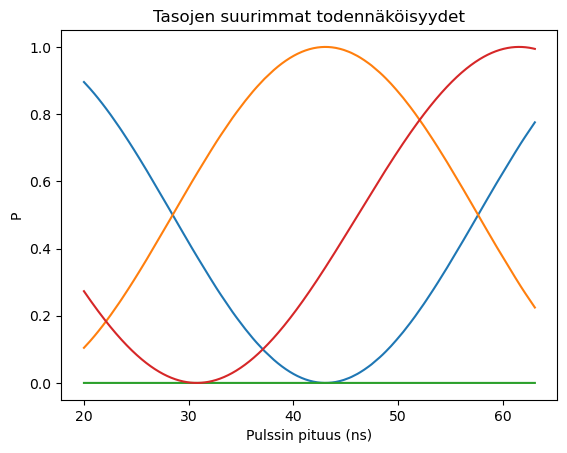

---------------------------------------------


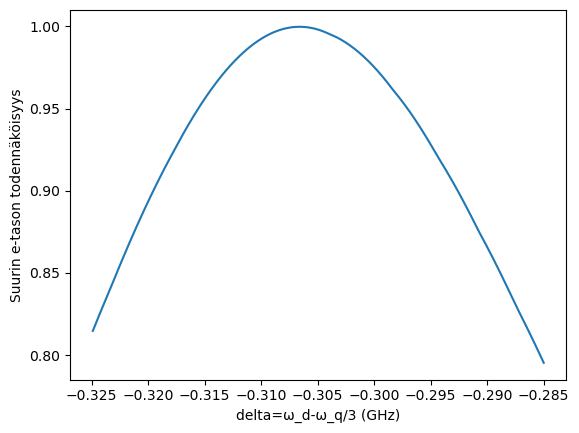

Amplitudi (GHz): 12.060132973240993
AC-stark siirtymä (GHz): -0.3065898535663432
E-tason suurin todennäköisyys: 0.9999567723192563
Pulssin pituus (ns): 39.18035425217539
Rabi-taajuus (fourier):  0.01908969363659234


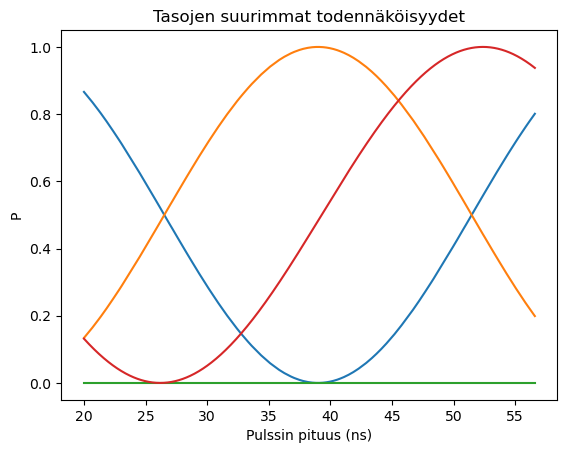

---------------------------------------------


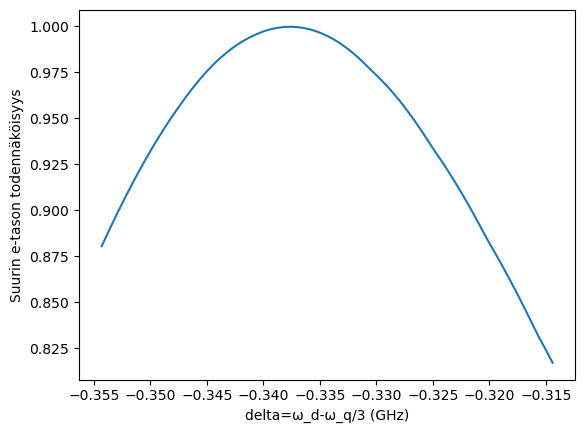

Amplitudi (GHz): 12.623565214482507
AC-stark siirtymä (GHz): -0.33760153186766884
E-tason suurin todennäköisyys: 0.9999609694185501
Pulssin pituus (ns): 35.4026086098583
Rabi-taajuus (fourier):  0.02229152529820326


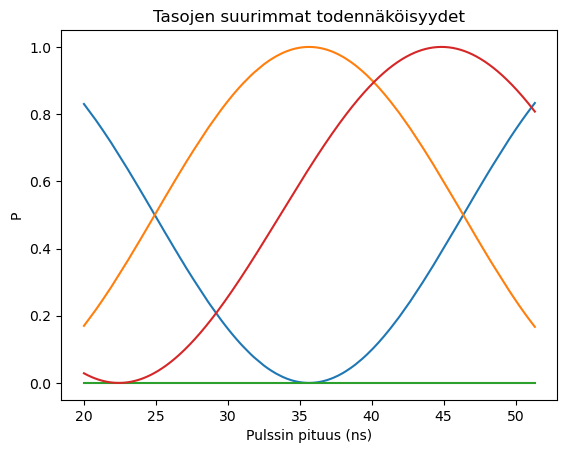

---------------------------------------------


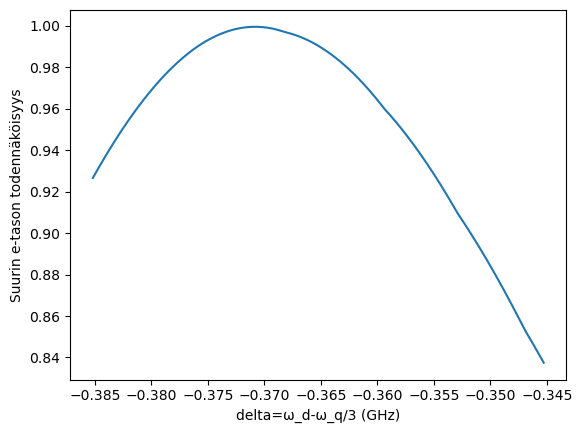

Amplitudi (GHz): 13.186997455724022
AC-stark siirtymä (GHz): -0.3707887451479009
E-tason suurin todennäköisyys: 0.9999739437811247
Pulssin pituus (ns): 33.145690818989095
Rabi-taajuus (fourier):  0.025886176943252067


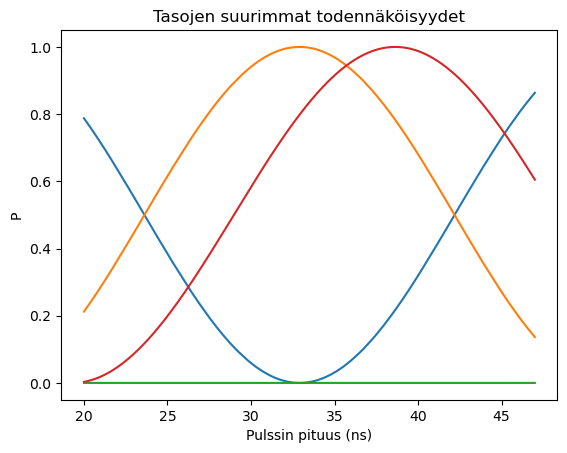

---------------------------------------------


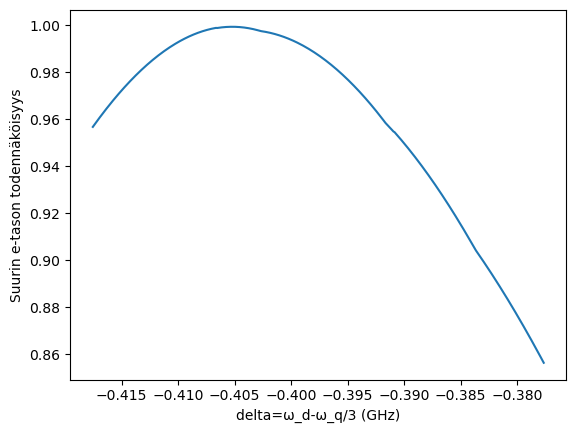

Amplitudi (GHz): 13.750429696965536
AC-stark siirtymä (GHz): -0.4052514934070396
E-tason suurin todennäköisyys: 0.9999375448068826
Pulssin pituus (ns): 30.871974922755946
Rabi-taajuus (fourier):  0.029892229016380303


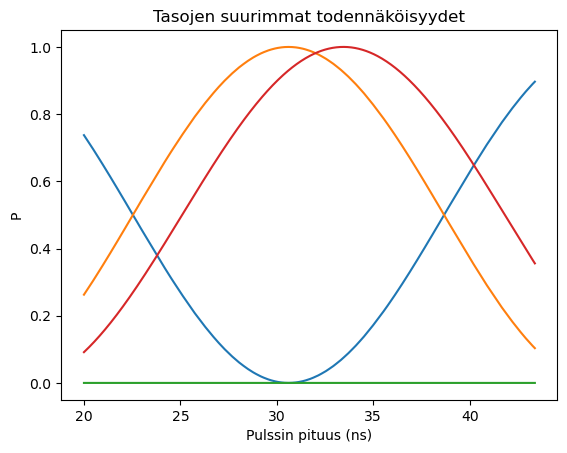

---------------------------------------------


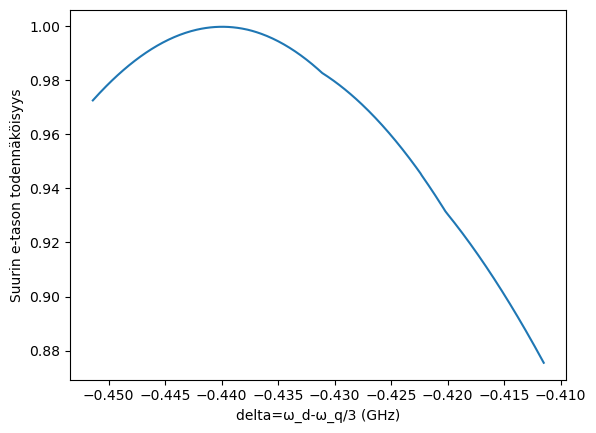

Amplitudi (GHz): 14.31386193820705
AC-stark siirtymä (GHz): -0.4398897766450849
E-tason suurin todennäköisyys: 0.9999417837267909
Pulssin pituus (ns): 28.578993669473924
Rabi-taajuus (fourier):  0.03434906881709559


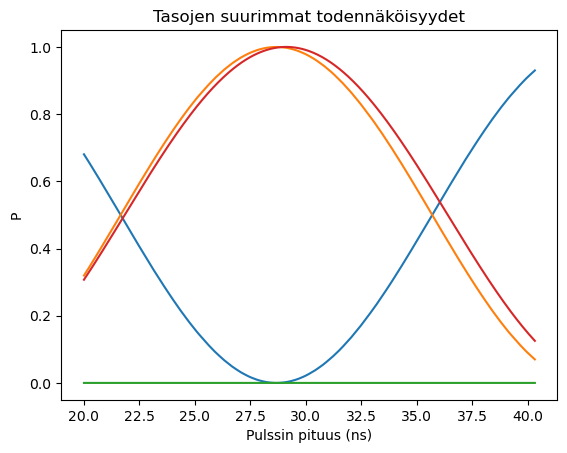

---------------------------------------------


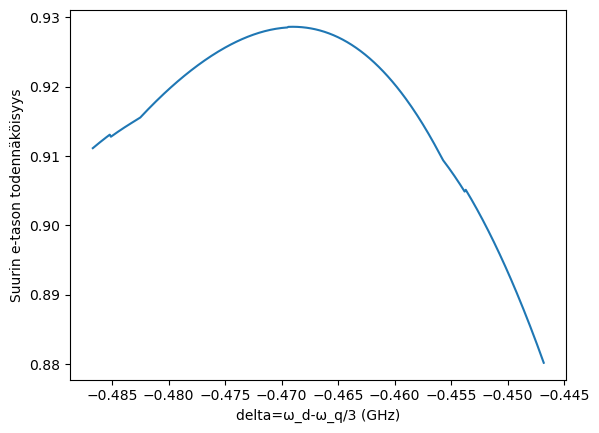

Amplitudi (GHz): 14.877294179448565
AC-stark siirtymä (GHz): -0.46900359486203663
E-tason suurin todennäköisyys: 0.9286131515130238
Pulssin pituus (ns): 26.261897307628757
Rabi-taajuus (fourier):  0.033664507529969474


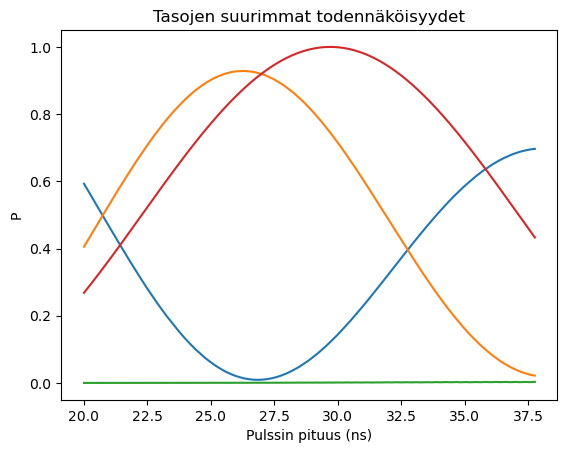

---------------------------------------------


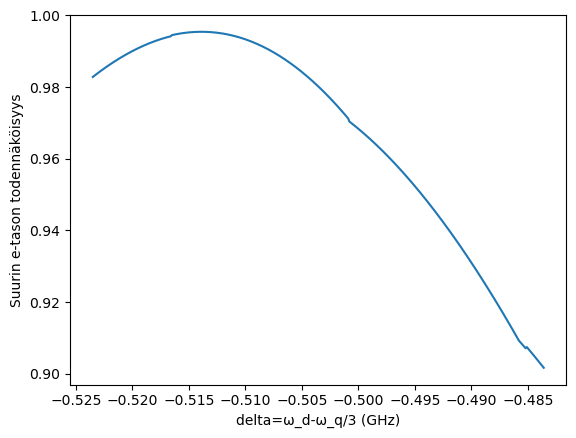

Amplitudi (GHz): 15.44072642069008
AC-stark siirtymä (GHz): -0.5138929480578952
E-tason suurin todennäköisyys: 0.9963866308671583
Pulssin pituus (ns): 25.50997278255862
Rabi-taajuus (fourier):  0.04471073850257815


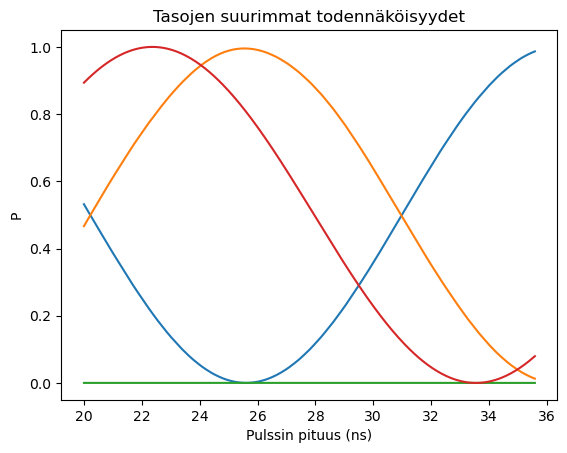

---------------------------------------------


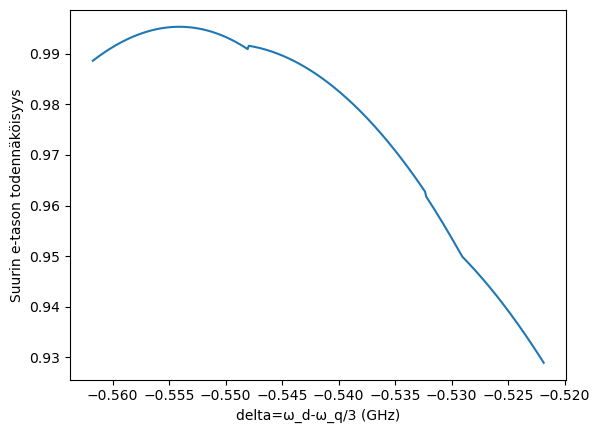

Amplitudi (GHz): 16.004158661931594
AC-stark siirtymä (GHz): -0.5540578362326601
E-tason suurin todennäköisyys: 0.9974017145287386
Pulssin pituus (ns): 24.746718060090483
Rabi-taajuus (fourier):  0.05066257546361618


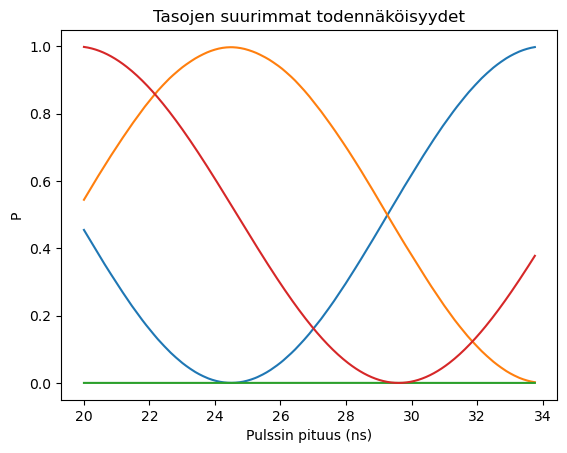

---------------------------------------------


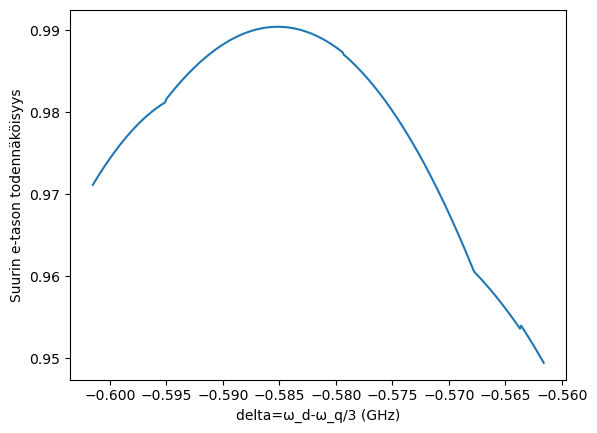

Amplitudi (GHz): 16.56759090317311
AC-stark siirtymä (GHz): -0.5850982593863318
E-tason suurin todennäköisyys: 0.9953835375355241
Pulssin pituus (ns): 23.176895024401492
Rabi-taajuus (fourier):  0.057175719411331795


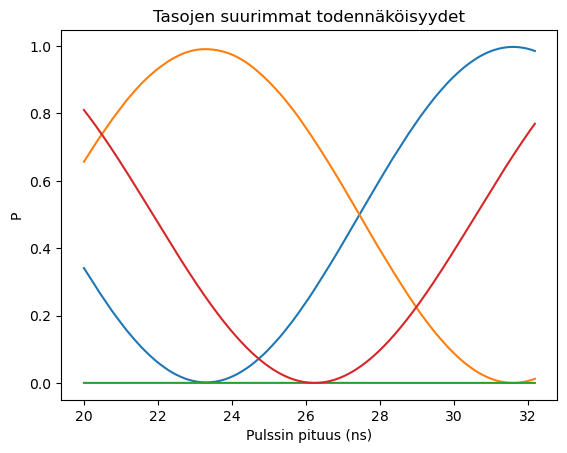

---------------------------------------------


In [ ]:
deltas = [] #AC Stark siirtymät
pulse_lengths = [] #Pulssin pituudet
max_vals = [] #Suurimmat tasojen todennäköisyydet
rabis = [] #Rabi taajuudet (fouriermuunnoksesta)
data = [] #e-tason suurimmat todennäköisyydet amplitudin ja AC-stark siirtymän suhteen
A_vals = [] #Ajavan amplitudin arvot

#Määritellään rajat amplitudille sekä simulaatioiden määrä
min_range = 0.23
max_range = 0.65
N_data=20
d_data=(max_range-min_range)/(N_data-1)

for i in range (0,N_data):
    
    A = qubit.frequency*(min_range+i*d_data)
    A_vals.append(A)

    f_rabi=2.875e-05*A**3 - 0.0003995*A**2 + 0.003097*A - 0.008257 #Arvaus Rabi-taajuudelle
    AC_stark=-0.002324*A**2 + 0.005164 *A - 0.01915 #Arvaus AC-stark siirtymälle
    if i < 7:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi*8,AC_stark,[-100,50],10000)
    else:
        params=find_params(qubit, A, evolution_eigenbasis,f_rabi*8,AC_stark,[-300,100],10000)
    deltas.append(params[0])
    pulse_lengths.append(params[1])
    data.append(params[3])
    
    f_d_opt = qubit.frequency/3+deltas[-1] #Löydetty optimaalinen ajotaajuus

    m=10
    vals = pulses.sim_3_part_pulses(f_d_opt,f_ef,A,evolution_eigenbasis,dim,(8*f_rabi)/m,t_ramp=10,U_f=0)

    print("Amplitudi (GHz):", A)
    print("AC-stark siirtymä (GHz):", deltas[-1])

    print("E-tason suurin todennäköisyys:", vals[0])
    print("Pulssin pituus (ns):", pulse_lengths[-1])
    
    max_vals.append([vals[0],vals[1]])

    g_vals=np.array([arr[0] for arr in vals[3]])
    e_vals=np.array([arr[1] for arr in vals[3]])
    f_vals=np.array([arr[2] for arr in vals[3]])

    g_vals_offset = g_vals-0.5 #Siirretään g-tason todennäköisyyksiä puolella alaspäin, dc-komponentin minimoinniksi
    fft_vals = np.fft.rfft(g_vals_offset) #Fourier-muunnos

    #Taajuusavaruus
    freqs = np.fft.rfftfreq(len(g_vals), d=vals[4][1]-vals[4][0]) 

    magnitude = np.abs(fft_vals) #Taajuuskomponentit
    magnitude[0] = 0 #Hylätään nollataajuus/vakiokomponentti

    frequency=freqs[np.argmax(magnitude)] #Suurin g-tason aikakehityksen taajuuskomponentti=Rabi-taajuus
    print("Rabi-taajuus (fourier): ",frequency)
    rabis.append(frequency)

    n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä
    
    plot_vals= 0.5*(1+np.cos(2*np.pi*frequency*vals[4][:n_picked])) #Sovite Rabi-taajuudella

    plt.figure()
    plt.plot(vals[4][:n_picked], g_vals[:n_picked])
    plt.plot(vals[4][:n_picked], e_vals[:n_picked])
    plt.plot(vals[4][:n_picked], f_vals[:n_picked])
    plt.plot(vals[4][:n_picked], plot_vals)
    plt.xlabel("Pulssin pituus (ns)")
    plt.ylabel("P")
    plt.title("Tasojen suurimmat todennäköisyydet")
    plt.show()

    print("---------------------------------------------")

[np.float64(5.862378319584331), np.float64(6.425810560825846), np.float64(6.98924280206736), np.float64(7.5526750433088745), np.float64(8.11610728455039), np.float64(8.679539525791904), np.float64(9.242971767033419), np.float64(9.806404008274933), np.float64(10.369836249516448), np.float64(10.933268490757962), np.float64(11.496700731999479), np.float64(12.060132973240993), np.float64(12.623565214482507), np.float64(13.186997455724022), np.float64(13.750429696965536), np.float64(14.31386193820705), np.float64(14.877294179448565), np.float64(15.44072642069008), np.float64(16.004158661931594), np.float64(16.56759090317311)]


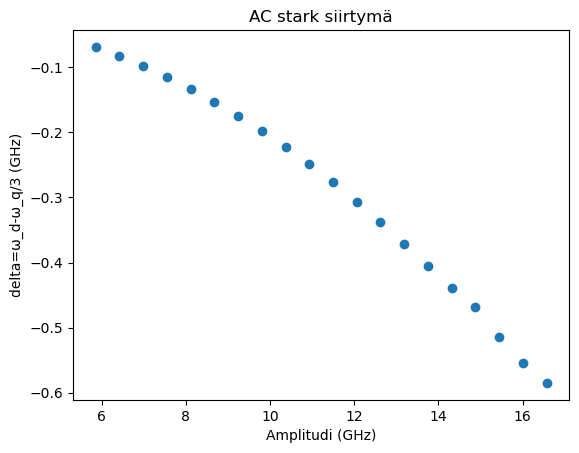

[np.float64(-0.06854670085959742), np.float64(-0.08262749439295047), np.float64(-0.09808382290521009), np.float64(-0.1149156863963763), np.float64(-0.13332308486644914), np.float64(-0.15320601831542852), np.float64(-0.1747644867433145), np.float64(-0.1977984901501071), np.float64(-0.22250802853580623), np.float64(-0.24889310190041194), np.float64(-0.27685371024392436), np.float64(-0.3065898535663432), np.float64(-0.33760153186766884), np.float64(-0.3707887451479009), np.float64(-0.4052514934070396), np.float64(-0.4398897766450849), np.float64(-0.46900359486203663), np.float64(-0.5138929480578952), np.float64(-0.5540578362326601), np.float64(-0.5850982593863318)]


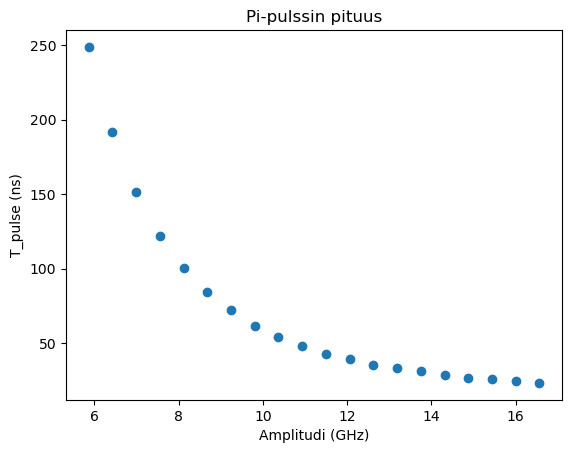

[np.float64(248.88195738790156), np.float64(191.76205947401442), np.float64(151.67721543211465), np.float64(121.95491795540768), np.float64(100.39108998689407), np.float64(84.01427624585332), np.float64(72.09915541305195), np.float64(61.64358306799366), np.float64(54.17377924753972), np.float64(48.188334226212035), np.float64(42.933155746030806), np.float64(39.18035425217539), np.float64(35.4026086098583), np.float64(33.145690818989095), np.float64(30.871974922755946), np.float64(28.578993669473924), np.float64(26.261897307628757), np.float64(25.50997278255862), np.float64(24.746718060090483), np.float64(23.176895024401492)]


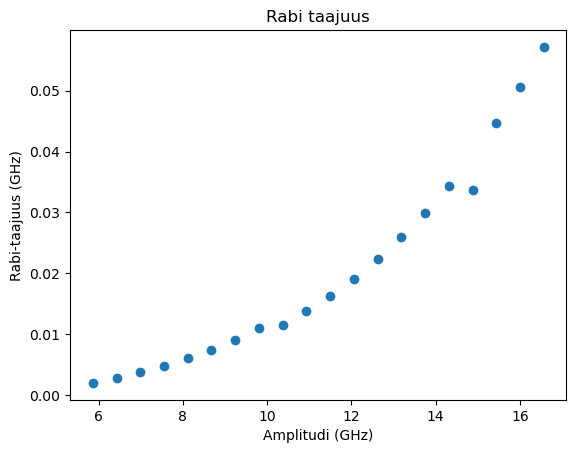

[np.float64(0.001997862955250715), np.float64(0.002827783917946332), np.float64(0.0037577979995352755), np.float64(0.0048193032621909725), np.float64(0.006043616758419821), np.float64(0.007462594716139585), np.float64(0.009107083852641373), np.float64(0.011008964365878712), np.float64(0.011549421551376997), np.float64(0.013746556158295455), np.float64(0.016250306393960662), np.float64(0.01908969363659234), np.float64(0.02229152529820326), np.float64(0.025886176943252067), np.float64(0.029892229016380303), np.float64(0.03434906881709559), np.float64(0.033664507529969474), np.float64(0.04471073850257815), np.float64(0.05066257546361618), np.float64(0.057175719411331795)]


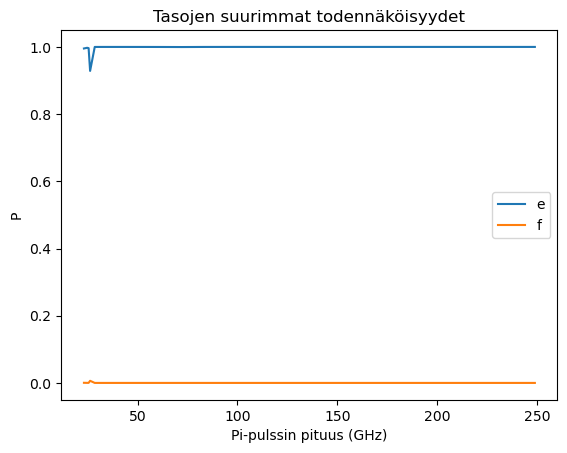

[np.float64(0.9999926759002367), np.float64(0.9999867478745655), np.float64(0.9999911238633302), np.float64(0.9999791620575094), np.float64(0.9999984531709478), np.float64(0.9999390948963529), np.float64(0.9996426698317941), np.float64(0.999842135766934), np.float64(0.999908471001111), np.float64(0.9999350753172572), np.float64(0.9999611094649057), np.float64(0.9999567723192563), np.float64(0.9999609694185501), np.float64(0.9999739437811247), np.float64(0.9999375448068826), np.float64(0.9999417837267909), np.float64(0.9286131515130238), np.float64(0.9963866308671583), np.float64(0.9974017145287386), np.float64(0.9953835375355241)]
[np.float64(8.521659753317993e-08), np.float64(1.1574977451623406e-07), np.float64(1.5392390883279163e-07), np.float64(1.8540463766895151e-07), np.float64(2.0611441864178503e-07), np.float64(9.587015574020775e-07), np.float64(4.373517180604432e-06), np.float64(1.1566300799575007e-06), np.float64(1.105427794383221e-06), np.float64(1.1913873428300518e-06), np.f

In [7]:
print(A_vals)

plt.figure()
plt.plot(A_vals, deltas, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("delta=ω_d-ω_q/3 (GHz)")
plt.title("AC stark siirtymä")
plt.show()
print(deltas)

plt.figure()
plt.plot(A_vals, pulse_lengths, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("T_pulse (ns)")
plt.title("Pi-pulssin pituus")
plt.show()
print(pulse_lengths)

plt.figure()
plt.plot(A_vals, rabis, 'o')
plt.xlabel("Amplitudi (GHz)")
plt.ylabel("Rabi-taajuus (GHz)")
plt.title("Rabi taajuus")
plt.show()
print(rabis)

e_vals=[arr[0] for arr in max_vals]
f_vals=[arr[1] for arr in max_vals]

plt.figure()
plt.plot(pulse_lengths, e_vals)
plt.plot(pulse_lengths, f_vals)
plt.legend(["e","f"])
plt.xlabel("Pi-pulssin pituus (GHz)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()
print(e_vals)
print(f_vals)

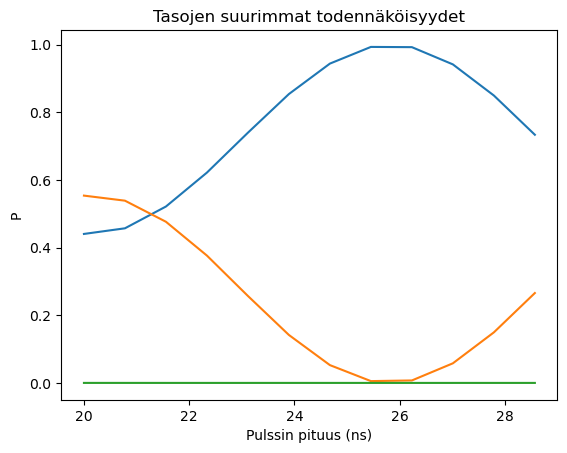

In [8]:
f_rabi=0.1
A=qubit.frequency*0.62
c=0.9591631891835839
m=1
vals = pulses.sim_3_part_pulses(qubit.frequency/3-0.42888093797878557,f_ef,A,evolution_eigenbasis,dim,(f_rabi*2*np.pi)/m,t_ramp=10,U_f=1,K=200)

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.plot(vals[4][:n_picked], g_vals[:n_picked])
plt.plot(vals[4][:n_picked], e_vals[:n_picked])
plt.plot(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()